# NODE / UDE - Remaining Useful Life (NASA C-MAPSS)

Este notebook implementa:

- Preprocesamiento de datos
- Construcción de RUL y probabilidad de falla
- NODE (Neural ODE)
- UDE (Universal Differential Equation)

In [1]:
using Pkg
Pkg.activate(".")

#solo la primera vez:
#Pkg.instantiate()

  Activating project at `c:\Users\usuario\Desktop\TP-DegradacionDeMotores\mi_entorno`


## Todas los paquetes que utilizaremos.

In [2]:
ENV["GKSwstype"] = "100"

using CSV
using DataFrames
using Statistics
using Plots

using Lux
using ComponentArrays
using Random
Random.seed!(42)

using OrdinaryDiffEq
using SciMLSensitivity

using Optimization
using OptimizationOptimisers
using Zygote

## Carga de datos

In [3]:
dataset_path = joinpath(pwd(), "..", "CMaps", "train_FD001.txt")

train_df = CSV.read(
    dataset_path,
    DataFrame;
    delim=' ',
    ignorerepeated=true,
    header=false
)


#agregamos los nombres de la columnas ya que el dataset original venian sin ellos
rename!(
    train_df,
    vcat(
        ["unit", "cycle", "setting1", "setting2", "setting3"],
        ["s$i" for i in 1:21]
    )
)

first(train_df, 5)

Row,unit,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Int64,Float64,Float64,Float64
1,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.7,1400.6,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.419
2,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.0,23.4236
3,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.2,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
4,1,4,0.0007,0.0,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
5,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.0,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.8,8.4294,0.03,393,2388,100.0,38.9,23.4044


## Normalización de sensores y settings

In [4]:
#Normalizamos los datos de los sensores y settings para mejorar entrenamiento de redes neuronales.


sensor_cols = ["s$i" for i in 1:21]
setting_cols = ["setting1", "setting2", "setting3"]
    
for col in sensor_cols
    μ = mean(train_df[!, col])
    σ_col = std(train_df[!, col])
    train_df[!, col] = (train_df[!, col] .- μ) ./ σ_col
end
    
for col in setting_cols
    μ = mean(train_df[!, col])
    σ_col = std(train_df[!, col])
    train_df[!, col] = (train_df[!, col] .- μ) ./ σ_col
end

## Construcción de RUL y probabilidad de falla.

In [5]:
#Construimos el cilo de falla. En el train la falla se da en el último ciclo observado.
fail_cycles = combine(
    groupby(train_df, :unit),
    :cycle => maximum => :T_fail
)

#Obtenemos un df de la siguiente forma:
#unit    T_fail
#1       192

#Ahora mergeamos con el dataset original
train_df = leftjoin(train_df, fail_cycles, on=:unit)

#Ahora empezamos a construir la proba de falla en cada ciclo.
train_df.RUL = train_df.T_fail .- train_df.cycle

#Para construir la proba vamos a utilizar un funcion sigmoide, que sea baja           lejos de la falla y aumenta rapido cerca de la falla.
      
σ(x) = 1 / (1 + exp(-x))


#Estos hiperparametros habria que chequearlos bien...
k = 0.08
threshold = 40
    
train_df.p_fail = σ.(k .* (threshold .- train_df.RUL))

20631-element Vector{Float64}:
 5.671790689635885e-6
 6.144174602214718e-6
 6.6559014820897696e-6
 7.2102480022617275e-6
 7.810763725056275e-6
 8.461293827645233e-6
 9.16600371985333e-6
 9.929405711774312e-6
 1.0756387901826074e-5
 1.165224547006964e-5
 ⋮
 0.9282424577362486
 0.9333919644249093
 0.9381965337364114
 0.9426758241011313
 0.9468488636019362
 0.9507339939159732
 0.9543488292155562
 0.9577102281579662
 0.9608342772032357

## Ejemplo de curva de falla

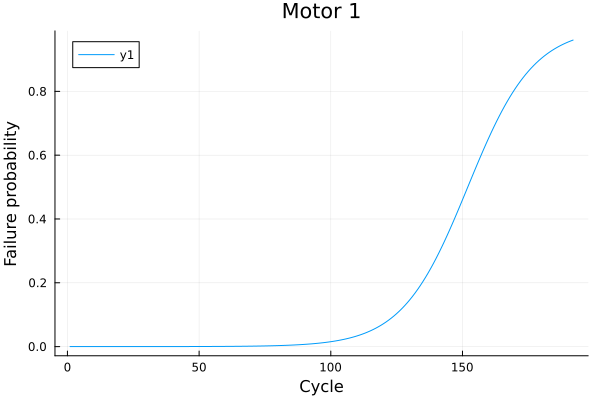

In [6]:
motor1 = filter(row -> row.unit == 1, train_df)
    
plt = plot(
    motor1.cycle,
    motor1.p_fail,
    xlabel="Cycle",
    ylabel="Failure probability",
    title="Motor 1"
)
    
plt

##  Trayectorias por motor

In [6]:
#agrupamos por unidad
grouped = groupby(train_df, :unit)
    
trajectories = []
    
for g in grouped
    X = Matrix(g[:, vcat(setting_cols, sensor_cols)])
    y = g.p_fail
    t = g.cycle
    
    push!(trajectories, (X=X, y=y, t=t))
end

##  NODE: dp/dt = NN(p, t)

NODE simple donde solo usamos los ciclos. Todavia no incorporamos sensores.

In [9]:
#elegimos una trayectoria
traj = trajectories[1]

print(trajectories)

t = Float64.(traj.t)
y = Float64.(traj.y)
    
u0 = [y[1]]
    
#generador de numeros aleatorios, sirve para inicializar los pesos de la red
rng = Random.default_rng()

#estructura de la red
nn = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

#p: parametros entrenables de la red, st: estados internos
p_node, st_node = Lux.setup(rng, nn)
#esto es para que funcione bien la optimizacion
p_node = ComponentArray(p_node)

Any[(X = [-0.31597202195452145 -1.3729199290729734 NaN 0.9999757643323645 -1.7216836648226865 -0.13425192213570927 -0.925913523696359 -0.9999757643323643 0.14167989491882235 1.1211133982073023 -0.516325892386186 -0.8627924043441415 0.9999757643323643 -0.2664601377187745 0.33425373913469153 -1.0588645739680291 -0.26906451920303553 -0.603801065881639 -0.9999757643323645 -0.7816908404632746 NaN NaN 1.3484600620382499 1.1943981001535333; 0.8727007771683792 -1.0316953503320596 NaN 0.9999757643323645 -1.0617539738121262 0.2115233673416215 -0.6437102649230355 -0.9999757643323643 0.14167989491882235 0.4319197071333588 -0.7980736570341316 -0.9587943771663178 0.9999757643323643 -0.1915782821843463 1.174870847738156 -0.3636371846989997 -0.6428291567796645 -0.27584512524895916 -0.9999757643323645 -0.7816908404632746 NaN NaN 1.0165032941737064 1.2368919830975704; -1.9618266668939224 1.015652122113423 NaN 0.9999757643323645 -0.6617965853206986 -0.4131555754405577 -0.5259404010255218 -0.9999757643323

Excessive output truncated after 524302 bytes.

1.2384462538215797 -1.0316953503320596 NaN 0.9999757643323645 -0.18184771913107628 -0.04617708424997548 -0.9248024872444967 -0.9999757643323643 0.14167989491882235 0.1155685046732259 0.6106651662055962 -1.2685365913660591 0.9999757643323643 -0.11669642664994466 0.42916212236418205 1.3049085495390833 -1.1015164749837953 0.4680549352104126 -0.9999757643323645 -0.13601426883344866 NaN NaN -0.8645850570586537 0.4701545299768707; -0.4531265756994716 1.6981012795952508 NaN 0.9999757643323645 -0.5418093687734067 0.4333414775723942 0.39177570821364166 -0.9999757643323643 0.14167989491882235 -0.16688792609477746 0.6106651662055962 -1.1734402975327907 0.9999757643323643 -0.04181457111551641 -0.6690634550049323 0.19254472671369463 -1.1549863109344234 -1.1983878525570615 -0.9999757643323645 1.1553388744262032 NaN NaN 0.8505249102414347 -0.4231407919119091; -0.9560266060976219 0.6744275433725094 NaN 0.9999757643323645 0.2581054082092214 -1.4521124593890253 -0.2859565274230445 -0.9999757643323643 0.

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.18582273 0.073365726; -1.3326262 1.9626849; … ; -1.2206342 0.22496898; 1.2360227 0.50070494], bias = Float32[0.45274794, -0.109943174, 0.2535509, 0.33633876, -0.58940434, -0.5645052, -0.6811371, -0.25305128, 0.11489113, 0.6639945, -0.4025346, -0.6888659, -0.4826754, 0.3613354, 0.48929778, -0.21674016]), layer_2 = (weight = Float32[0.3199716 0.046035804 … 0.03958083 -0.19888853], bias = Float32[-0.0893096]))

Definimos la NODE

In [9]:
function node!(du, u, p, t)
    input = [u[1], t]

    du .= nn(input, p, st_node)[1]
end

node! (generic function with 1 method)

In [10]:
#todo el intervalo de tiempo
tspan = (t[1], t[end])
	
#definimos el problema de ode
prob_node = ODEProblem(node!, u0, tspan, p_node)
	
#resolvemos con solver numerico
sol = solve(prob_node, Tsit5(), saveat=t)

retcode: Success
Interpolation: 1st order linear
t: 192-element Vector{Float64}:
   1.0
   2.0
   3.0
   4.0
   5.0
   6.0
   7.0
   8.0
   9.0
  10.0
   ⋮
 184.0
 185.0
 186.0
 187.0
 188.0
 189.0
 190.0
 191.0
 192.0
u: 192-element Vector{Vector{Float64}}:
 [5.671790689635885e-6]
 [-0.6389859493328393]
 [-1.1971182814602073]
 [-1.690072756169595]
 [-2.1514591085398314]
 [-2.5924914293618455]
 [-3.0142288955066787]
 [-3.41512428090587]
 [-3.7941918771853764]
 [-4.152477724694881]
 ⋮
 [-73.60671244711838]
 [-74.01172685927285]
 [-74.41675030417355]
 [-74.82178185297677]
 [-75.22682058487337]
 [-75.63186558708865]
 [-76.03691595488252]
 [-76.44197079154928]
 [-76.84702920841788]

## Predicción sin entrenamiento

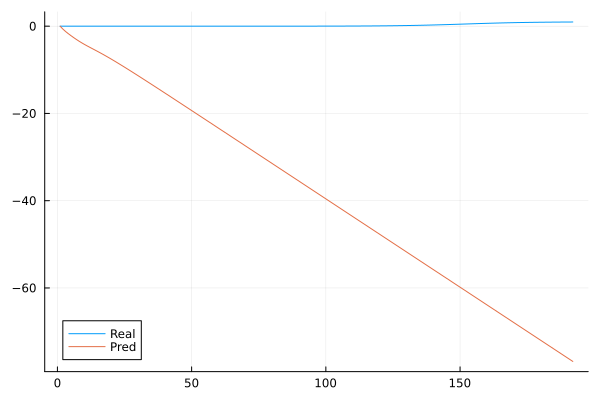

In [11]:
plt2 = plot(t, y, label="Real")
plot!(plt2, t, vec(Array(sol)), label="Pred")
	
plt2

Como se puede observar, al no haber entrenado la red no obtenemos buenos resultados.

##  Entrenamiento NODE

In [12]:
#funcion de prediccion
function predict(prob, p, t)

    _prob = remake(prob, p=p)
    
    sol = solve(
        _prob,
        Tsit5(),
        saveat=t
    )
    
    Array(sol)[1, :]
end

#funcion de perdida basica
function loss(prob, p, t, y)

    pred = predict(prob, p, t)
    
    sum(abs2, pred .- y)

end

loss (generic function with 1 method)

In [13]:
#convertimos la funcion loss en algo digerible por el optimizador. Con AutoZygote() calculamos los gradientes.
optf_node = OptimizationFunction((x, _) -> loss(prob_node,x,t,y), AutoZygote())

#Define el problema de opt. Quiero minimizar optf empezando de parametros iniciales p.
optprob_node = OptimizationProblem(optf_node, p_node)

#Resulve el problema de opt. Con Adam version de descenso por el gradiente y 0.01 el learning rate.
result_node = Optimization.solve(optprob_node, Adam(0.01), maxiters=500)
	
p_trained_node = result_node.u

#prediccion final luego de entrenar:
pred_node = predict(prob_node, p_trained_node, t)

192-element Vector{Float64}:
  5.671790689635885e-6
 -0.04486189459213208
 -0.09923701153516558
 -0.10557307590261993
 -0.08825253220874044
 -0.06583979844147159
 -0.0454655777956574
 -0.028559856620187892
 -0.01470540925328058
 -0.003102457060216534
  ⋮
  0.5138622514178848
  0.5163580730718544
  0.5190931110050987
  0.5218390301951028
  0.5244324199162117
  0.5268896469724834
  0.5294020026491865
  0.5320855595302143
  0.5347326611146708

Graficamos la sol obtenida

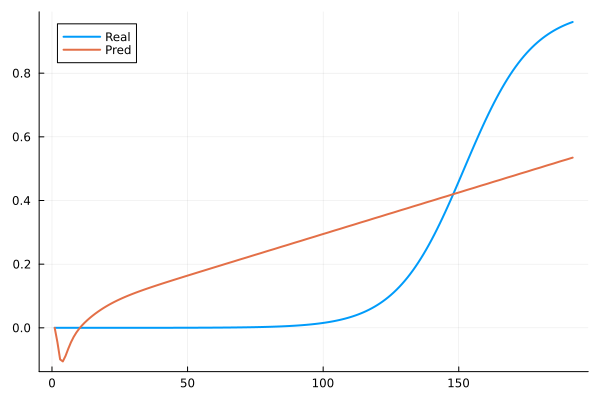

In [14]:
p1 = plot(
        t,
        y,
        label="Real",
        linewidth=2
    )
    
plot!(
    p1,
    t,
    pred_node,
    label="Pred",
    linewidth=2
)

p1

##  UDE: término físico + red neuronal

dp/dt = -αu + NN(p,t) 

In [34]:
#Definimos la red
nn2 = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

#parametros y estado interno
p_ude, st_ude = Lux.setup(rng, nn2)
p_ude = ComponentArray(p_ude)
    
α = 0.05

#definimos ude
function ude!(du, u, p, t)

    input = [u[1], t]
    du .= .-α .* u .+ nn2(input, p, st_ude)[1]

end

#definimos problema ode
prob_ude = ODEProblem(ude!, u0, tspan, p_ude)

#mismo proceso de antes
optf_ude = OptimizationFunction(
(x, _) -> loss(prob_ude,x,t,y),
AutoZygote()
)

optprob_ude = OptimizationProblem(optf_ude, p_ude)

result_ude = Optimization.solve(
    optprob_ude,
    Adam(0.01),
    maxiters=500
)

p_trained_ude = result_ude.u
pred_ude = predict(prob_ude, p_trained_ude, t)

192-element Vector{Float64}:
  5.671790689635885e-6
 -0.19684063676196734
 -0.23728147297881533
 -0.22248575859507905
 -0.18407848575635274
 -0.1390638651352417
 -0.0977686836671372
 -0.06459688570178193
 -0.0396488619134343
 -0.021146289550229343
  ⋮
  0.6248849767448977
  0.6295627085098326
  0.634207151673718
  0.63882803196489
  0.6434427355570794
  0.6480763090694109
  0.6527613736191462
  0.6574741362882324
  0.6621757879931054

Graficamos la sol obtenida:

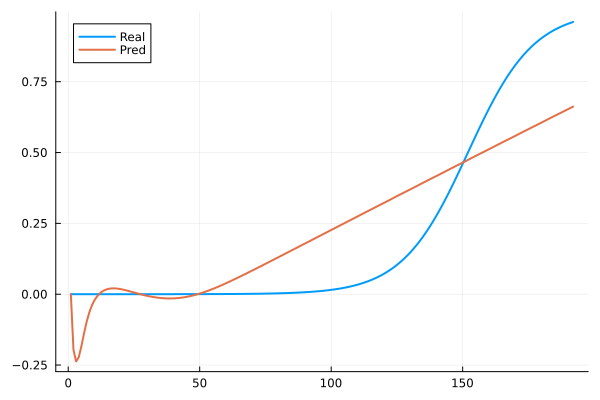

In [35]:
p2 = plot(
    t,
    y,
    label="Real",
    linewidth=2
    )
    
plot!(
    p2,
    t,
    pred_ude,
    label="Pred",
    linewidth=2
)

##  UDE: término físico + red neuronal agregando motores


In [36]:
#Ahora tengamos en cuenta mas de una trayectoria de motor.

#hago una funcion para no practicar con todas las trajs a la ves, si no tarda demasiado

n_motors = length(trajectories)


function build_train_trajs(trajectories; n_motors=nothing, shuffle=false, seed=1234)

    total_motors = length(trajectories)

    if n_motors === nothing
        selected_ids = collect(1:total_motors)
    else
        n = min(n_motors, total_motors)
        println("usando $n de $total_motors motores")
        selected_ids = collect(1:n)
    end


    #esto recontraponele, capaz sirve capaz no, pero como el test te da cualquier motor esto lo hace mas random
    if shuffle
        rng = Random.default_rng()
        Random.seed!(rng, seed)
        selected_ids = selected_ids[randperm(rng, length(selected_ids))]
    end

    train_trajs = [
        (
            X = trajectories[i].X,
            t = Float64.(trajectories[i].t),
            y = Float64.(trajectories[i].y)
        )
        for i in selected_ids
    ]

    return train_trajs
end

function predict_traj(f!, p, traj)

    t = traj.t
    y = traj.y

    u0 = [y[1]]
    tspan = (t[1], t[end])

    prob = ODEProblem(f!, u0, tspan, p)

    sol = solve(
        prob,
        Tsit5(),
        saveat=t,
        abstol=1e-6,
        reltol=1e-6
    )

    return Array(sol)[1, :]
end

function loss_many(f!, p, trajs)

    total_loss = 0.0
    total_points = 0

    for traj in trajs
        pred = predict_traj(f!, p, traj)
        y = traj.y

        total_loss += sum(abs2, pred .- y)
        total_points += length(y)
    end

    return total_loss / total_points
end

loss_many (generic function with 1 method)

La función de pérdida total sobre varios motores se define como:

$$
\mathcal{L}(\theta)
=
\frac{1}{\sum_{i=1}^{M} T_i}
\sum_{i=1}^{M}
\sum_{j=1}^{T_i}
\left(
\hat{y}_{i,j}(\theta) - y_{i,j}
\right)^2
$$

In [45]:
#para las pruebas vamos con 10.



# Definimos la red de la UDE
nn2 = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

# Parámetros y estado interno
p_ude, st_ude = Lux.setup(rng, nn2)
p_ude = ComponentArray(p_ude)

# Parámetro fijo de la parte mecanística
α = 0.05




0.05

In [ ]:
train_trajs = build_train_trajs(trajectories, n_motors=10)

optf_ude = OptimizationFunction(
    (x, _) -> loss_many(ude!, x, train_trajs),
    AutoZygote()
)

optprob_ude = OptimizationProblem(optf_ude, p_ude)

result_ude = Optimization.solve(
    optprob_ude,
    Adam(0.01),
    maxiters=500
)

p_trained_ude = result_ude.u

ComponentVector{Float32}(layer_1 = (weight = Float32[-1.5359433 1.1361357; 1.710526 1.3938317; … ; 1.8157877 1.2192338; -0.3214584 -1.1227524], bias = Float32[-0.13734937, -0.6569444, -0.39522463, -0.11413398, -0.2366285, -0.4209578, 0.37474266, 0.42246935, 0.34996846, -0.13300526, -0.37029004, 0.6554874, 0.56810844, -0.3545722, 0.40711337, -0.011209199]), layer_2 = (weight = Float32[-0.13483146 -0.16255611 … 0.08784529 -0.12164354], bias = Float32[0.0985095]))

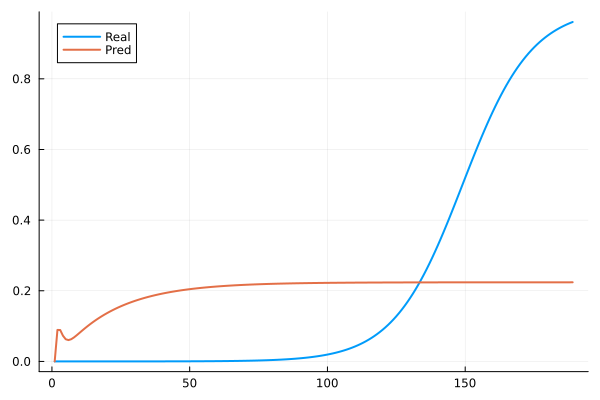

In [ ]:
traj_plot = train_trajs[4]

pred_ude_n = predict_traj(ude!, p_trained_ude, traj_plot)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_n,
    label="Pred",
    linewidth=2
)

Empeora bastante... Esto puede ser ya que estoy intentando generalizar para todos los motores, sin tener cuenta los sensores. entonces, cuando veo para el caso particular 1, no calcula bien.

Si aumento cnt de motores a 30:


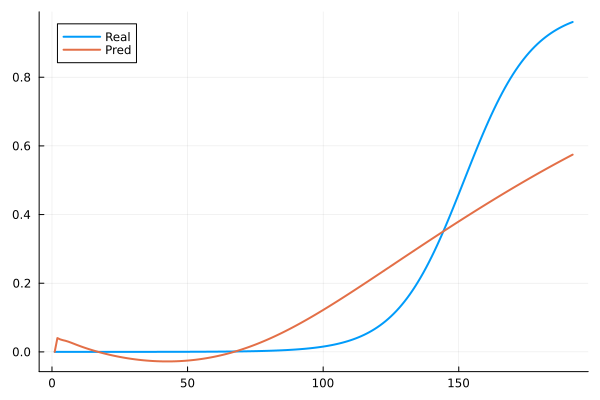

In [51]:


# Definimos la red de la UDE
nn2 = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

# Parámetros y estado interno
p_ude, st_ude = Lux.setup(rng, nn2)
p_ude = ComponentArray(p_ude)

# Parámetro fijo de la parte mecanística
α = 0.05


train_trajs = build_train_trajs(trajectories, n_motors=30)

optf_ude = OptimizationFunction(
    (x, _) -> loss_many(ude!, x, train_trajs),
    AutoZygote()
)

optprob_ude = OptimizationProblem(optf_ude, p_ude)

result_ude = Optimization.solve(
    optprob_ude,
    Adam(0.01),
    maxiters=500
)

p_trained_ude = result_ude.u

traj_plot = train_trajs[1]

pred_ude_n = predict_traj(ude!, p_trained_ude, traj_plot)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_n,
    label="Pred",
    linewidth=2
)

##  UDE: término físico + red neuronal + sensores para 1 (un) motor (no sabes lo q tarda en correr con 10)

dp/dt = -αu + NN(p,t,sens) 

In [10]:
function build_train_trajs_sensors(trajectories; n_motors=nothing, shuffle=false, seed=67)

    total_motors = length(trajectories)

    selected_ids = collect(1:total_motors)

    if shuffle
        rng = MersenneTwister(seed)
        selected_ids = selected_ids[randperm(rng, length(selected_ids))]
    end

    if n_motors !== nothing
        n = min(n_motors, total_motors)
        println("usando $n de $total_motors motores")
        selected_ids = selected_ids[1:n]
    end

    train_trajs = [
        (
            S = Float64.(trajectories[i].X[:, 4:end]),  # solo sensores
            t = Float64.(trajectories[i].t),
            y = Float64.(trajectories[i].y)
        )
        for i in selected_ids
    ]

    return train_trajs
end

build_train_trajs_sensors (generic function with 1 method)

In [11]:
train_trajs_sensors = build_train_trajs_sensors(
    trajectories;
    n_motors=1
)
n_sensors = size(train_trajs_sensors[1].S, 2)

println("Cantidad de sensores usados: ", n_sensors)

input_dim = 2 + n_sensors

nn2 = Lux.Chain(
    Lux.Dense(input_dim, 32, tanh), #aumente entrada para incluir sensores
    Lux.Dense(32, 16, tanh),
    Lux.Dense(16, 1)
)

p_ude_sensors, st_ude_sensors = Lux.setup(rng, nn2)
p_ude_sensors = ComponentArray(p_ude_sensors)

α = 0.05


function ude_sensors!(du, u, p, τ, S)

    input = Float32.(vcat([u[1], τ], S))

    out, _ = nn2(input, p, st_ude_sensors)

    du[1] = -α * u[1] + out[1]

end


function predict_traj_sensors(p, traj)

    tvec = traj.t
    y = traj.y
    S_traj = traj.S

    u0 = [y[1]]

    t0 = tvec[1]
    tf = tvec[end]
    tspan = (t0, tf)

    function f!(du, u, p, t)

        idx = searchsortedlast(tvec, t) #a ver, esto es para encontrar el indice del tiempo actual en el vector de tiempos de la trayectoria porque la red usa ts intermedios (t=0.5 ponele) y ahi
                                        #no hay sensores. Entonces buscamos el indice del tiempo mas cercano que no sea mayor a t, y usamos los sensores de ese indice. es una aprox, hay q charlarlo

        S = vec(S_traj[idx, :])

        τ = (t - t0) / (tf - t0)

        ude_sensors!(du, u, p, τ, S)

    end

    prob = ODEProblem(f!, u0, tspan, p)

    sol = solve(
        prob,
        Tsit5(),
        saveat=tvec,
        abstol=1e-6,
        reltol=1e-6
    )

    return Array(sol)[1, :]

end

predict_traj_sensors (generic function with 1 method)

In [12]:
function loss_many_sensors(p, trajs)

    total_loss = 0.0
    total_points = 0

    for traj in trajs
        pred = predict_traj_sensors(p, traj)
        y = traj.y

        total_loss += sum(abs2, pred .- y)
        total_points += length(y)
    end

    return total_loss / total_points

end

loss_many_sensors (generic function with 1 method)

In [ ]:
optf_ude_sensors = OptimizationFunction(
    (x, _) -> loss_many_sensors(x, train_trajs_sensors),
    AutoZygote()
)

optprob_ude_sensors = OptimizationProblem(
    optf_ude_sensors,
    p_ude_sensors
)

result_ude_sensors = Optimization.solve(
    optprob_ude_sensors,
    Adam(0.01),
    maxiters=500
)

p_trained_ude_sensors = result_ude_sensors.u

In [ ]:
traj_plot = train_trajs_sensors[1]

pred_ude_sensors = predict_traj_ude_sensors(
    p_trained_ude_sensors,
    traj_plot
)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_sensors,
    label="Pred UDE + sensores",
    linewidth=2
)

p2

In [ ]:
println("hola") #No me andan los prints no se q pija pasa